In [1]:
import string
from random import random

import torch
from models import *

data = open('names.txt', 'r').read().splitlines(keepends=False)
print(data[:5])

['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [2]:
bigram = Bigram()
bigram.fit(data)

In [3]:
bigram.make(5)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [4]:
bigram.loss(data)

2.4543561935424805

In [2]:
generator = torch.Generator().manual_seed(1234)
nn = NN(generator=generator)

nn.fit(data)

Loss=2.4627


In [3]:
generator = torch.Generator().manual_seed(1234)
nn.make(generator=generator)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [2]:
stoi = {s: i+1 for i, s in enumerate(string.ascii_lowercase)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [3]:
context_size = 3

def build_datasets(data):
    X, Y = [], []
    for word in data:
        context = [0] * context_size
        for char in word + '.':
            idx = stoi[char]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]

    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(data)

n1 = int(len(data) * 0.8)
n2 = int(len(data) * 0.9)

Xtrain, ytrain = build_datasets(data[:n1])
Xdev, ydev = build_datasets(data[n1:n2])
Xtest, ytest = build_datasets(data[n2:])

In [4]:
vocab_size = len(stoi) # 27
n_embed = 10
n_hidden = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed), generator=g)

layers = [
    Linear(fan_in=context_size * n_embed, fan_out=n_hidden,   generator=g, gain = 5./3.,   bias=False), BatchNorm1d(n_hidden),   Tanh(),
    Linear(fan_in=n_hidden,               fan_out=n_hidden,   generator=g, gain = 5./3.,   bias=False), BatchNorm1d(n_hidden),   Tanh(),
    Linear(fan_in=n_hidden,               fan_out=n_hidden,   generator=g, gain = 5./3.,   bias=False), BatchNorm1d(n_hidden),   Tanh(),
    Linear(fan_in=n_hidden,               fan_out=n_hidden,   generator=g, gain = 5./3.,   bias=False), BatchNorm1d(n_hidden),   Tanh(),
    Linear(fan_in=n_hidden,               fan_out=n_hidden,   generator=g, gain = 5./3.,   bias=False), BatchNorm1d(n_hidden),   Tanh(),
    Linear(fan_in=n_hidden,               fan_out=vocab_size, generator=g, gain = 5./3.,   bias=False), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    layers[-1].scale *= 0.1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum([p.nelement() for p in parameters]))

for p in parameters:
    p.requires_grad = True

47024


In [5]:
n_epochs = 100_000
batch_size = 32
ud = []

for epoch in range(n_epochs):
    # get batch
    idx = torch.randint(0, Xtrain.shape[0], (batch_size, ))
    Xb, Yb = Xtrain[idx], ytrain[idx]

    emb = C[Xb]
    x = emb.view((emb.shape[0], -1))
    # forward pass
    for layer in layers:
        x = layer(x)

    # loss
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    lr = 0.1 if epoch < n_epochs / 2 else 0.05
    for p in parameters:
        p.data += -lr * p.grad

    if epoch % 10000 == 0:
        print(f'{epoch}/{n_epochs} {loss:.4f}')

    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])

loss

0/100000 3.2706
10000/100000 2.2804
20000/100000 1.9524
30000/100000 2.2636
40000/100000 2.3049
50000/100000 1.8994
60000/100000 2.1320
70000/100000 1.9182
80000/100000 2.1063
90000/100000 2.1981


tensor(2.0348, grad_fn=<NllLossBackward0>)

layer 2 (Tanh): mean: 0.01, std: 0.70, saturated: 11.84%
layer 5 (Tanh): mean: -0.00, std: 0.72, saturated: 13.97%
layer 8 (Tanh): mean: -0.02, std: 0.73, saturated: 14.34%
layer 11 (Tanh): mean: -0.02, std: 0.74, saturated: 12.91%
layer 14 (Tanh): mean: -0.02, std: 0.75, saturated: 13.97%


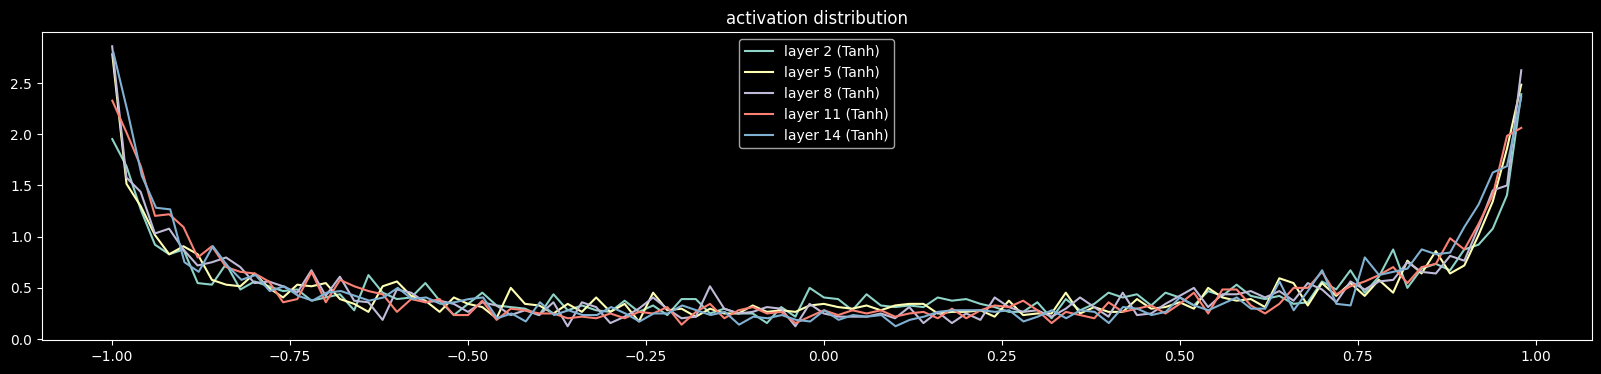

In [6]:
import histograms as H

H.activation_dist(layers)

Layer 2 (Tanh): mean -0.000000 std: 3.674902e-03
Layer 5 (Tanh): mean -0.000000 std: 3.537762e-03
Layer 8 (Tanh): mean -0.000000 std: 3.501652e-03
Layer 11 (Tanh): mean -0.000000 std: 3.259094e-03
Layer 14 (Tanh): mean -0.000000 std: 3.375394e-03


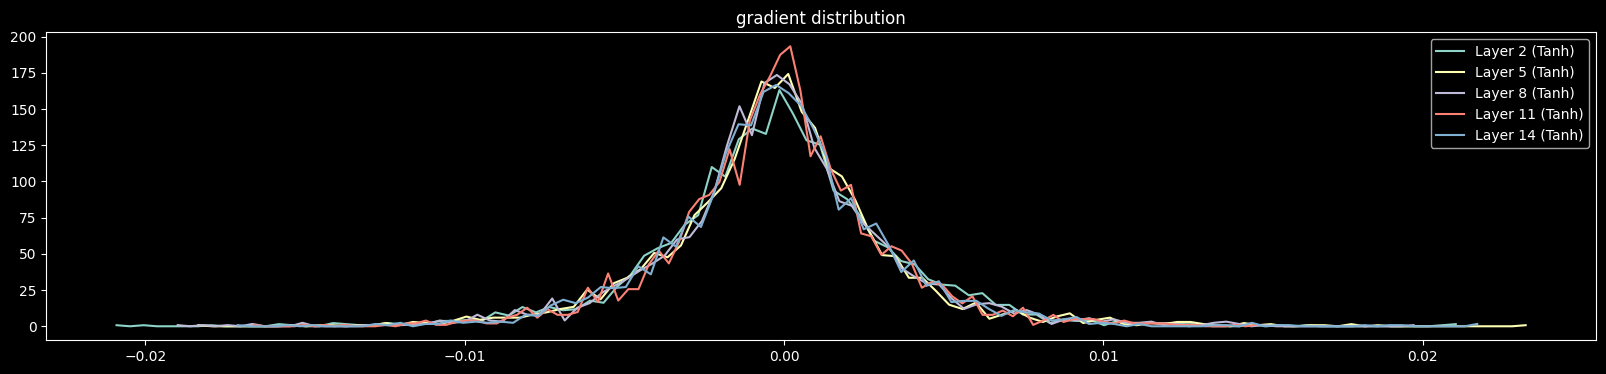

In [7]:
H.gradient_distribution(layers)

weight (27, 10) | mean: -0.000000 | std: 1.329509e-02 | grad:data ratio 1.260983e-02
weight (30, 100) | mean: -0.000172 | std: 8.693460e-03 | grad:data ratio 2.295728e-02
weight (100, 100) | mean: +0.000081 | std: 5.946293e-03 | grad:data ratio 2.649697e-02
weight (100, 100) | mean: -0.000071 | std: 5.826753e-03 | grad:data ratio 2.630260e-02
weight (100, 100) | mean: -0.000009 | std: 5.572459e-03 | grad:data ratio 2.560715e-02
weight (100, 100) | mean: +0.000079 | std: 5.181016e-03 | grad:data ratio 2.458699e-02
weight (100, 27) | mean: +0.000004 | std: 8.956651e-03 | grad:data ratio 3.094712e-02


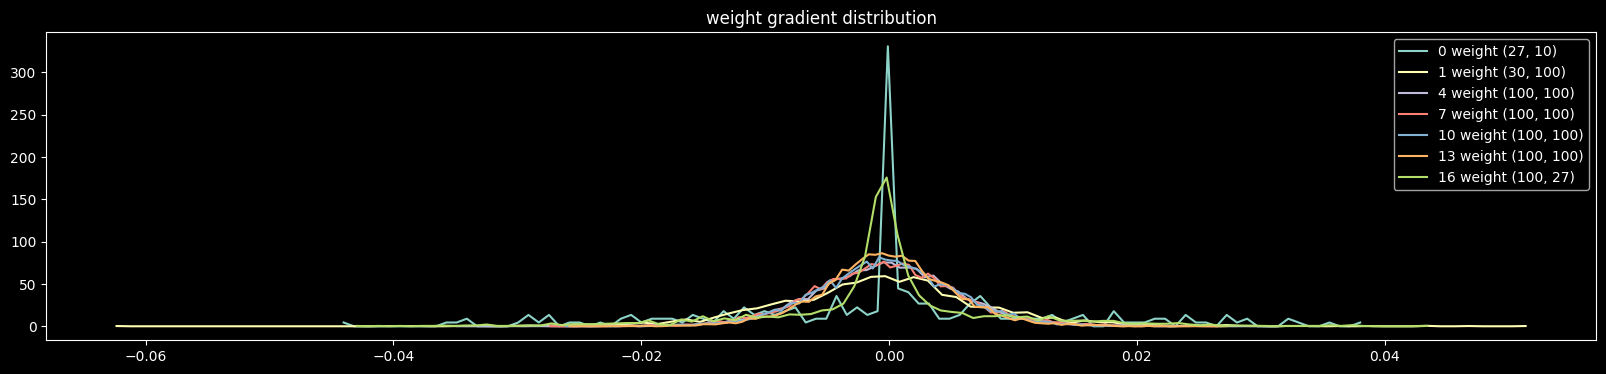

In [8]:
H.weight_gradient_dist(parameters)

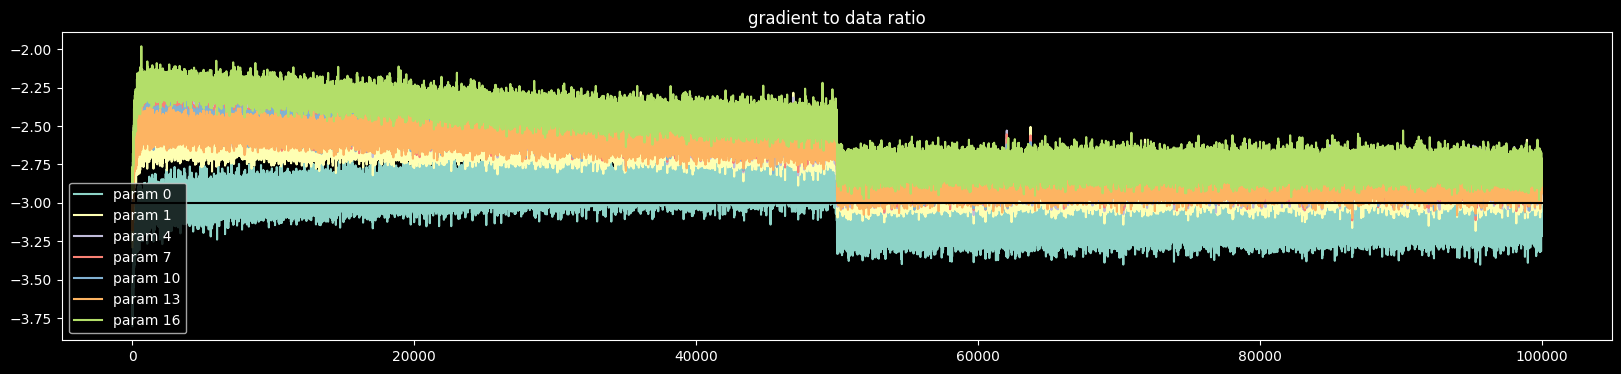

In [9]:
H.grad_data_ratio(parameters, ud)

In [10]:
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

with torch.no_grad():
    idx = torch.randint(0, Xdev.shape[0], (batch_size, ))
    Xb, Yb = Xdev[idx], ydev[idx]

    emb = C[Xb]
    x = emb.view((emb.shape[0], -1))
    # forward pass
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

loss

tensor(2.1165)

In [11]:
g = torch.Generator().manual_seed(2147483647 + 10)

def generate(count = 20):
    for layer in layers:
        if isinstance(layer, BatchNorm1d):
            layer.training = False

    out = []
    for i in range(count):
        context = [0] * context_size
        res = []

        while True:
            emb = C[torch.tensor([context])]
            x = emb.view((emb.shape[0], -1))
            # forward pass
            for layer in layers:
                x = layer(x)

            probs = F.softmax(x, dim=1)
            pred = torch.multinomial(probs, 1, generator=g).item()

            res.append(pred)
            context = context[1:] + [pred]

            if pred == 0:
                break

        out.append(''.join(itos[i] for i in res))

    return out

generate()

['carman.',
 'amelle.',
 'khyimri.',
 'reh.',
 'cassanden.',
 'jazhith.',
 'deliah.',
 'jareen.',
 'ner.',
 'keagcheiivia.',
 'leigh.',
 'ham.',
 'prin.',
 'quinthonovana.',
 'jadiquinterri.',
 'jaryxia.',
 'kaelyius.',
 'bred.',
 'emiia.',
 'gian.']